<p style="text-align:center"> 
    <a href="https://www.linkedin.com/in/flavio-aguirre-12784a252/" target="_blank"> 
    <img src="../assets/logo.png" width="200" alt="Flavio Aguirre Logo"> 
    </a>
</p>

<h1 align="center"><font size="7"><strong>📉 ByeBye Predictor</strong></font></h1>
<br>
<hr>

## Reddit Churn Intent – Training and Evaluation

**Date:** November 29, 2025  
**Subject:** Churn-intent classification from Reddit comments

In Notebook 06 we:

- Cleaned and labeled a dataset of **Reddit comments** from telco-related threads.
- Defined a simple `churn_signal` label based on explicit mentions of leaving or switching providers.
- Designed a **text feature pipeline** using `TextCleaner` + TF-IDF + optional SVD.
- Saved the curated dataset as `reddit_comments_labeled.csv` in `data/processed/`.

In this notebook we will:

1. Load the **labeled Reddit comments dataset**.
2. Train a **text-based churn-intent classifier**, `churn_text_model`.
3. Evaluate the model using standard classification metrics and simple plots.
4. Extract a **text-based churn risk score** (`nlp_churn_score`) using `predict_proba`.
5. Discuss how this risk score can be integrated into the main Telco churn pipeline.

The goal is not to build a state-of-the-art NLP model, but to show a **clean, interpretable and production-friendly** way to turn unstructured feedback into churn signals.

In [1]:
### Imports and setup
from notebooks_setup import PROJECT_ROOT

# Local
from src.utils import get_logger
from src.data_loader import load_csv, save_df, config as dl_config
from src.preprocess import TextCleaner
from src.eda import (
    plot_target_distribution,
    plot_numerical_distributions,
    config as eda_config,
)

# External
from pathlib import Path
import os
import glob
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_predict, StratifiedKFold
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression

%matplotlib inline

logger = get_logger(__name__)

# EDA output dir for this notebook
eda_config.out_dir = "reports/figures/reddit-comments-nlp"
eda_config.apply()

2025-11-29 22:55:58,544 | utils | INFO | Added project root to sys.path: C:\Users\Pc\Desktop\github
2025-11-29 22:55:59,824 | src.preprocess | INFO | NLTK resource 'punkt' is already downloaded.
2025-11-29 22:55:59,827 | src.preprocess | INFO | NLTK resource 'stopwords' is already downloaded.
2025-11-29 22:55:59,831 | src.preprocess | WARNING | NLTK resource 'wordnet' not found. Downloading...
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Pc\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
2025-11-29 22:55:59,930 | src.preprocess | INFO | NLTK resource 'punkt_tab' is already downloaded.
2025-11-29 22:55:59,931 | src.preprocess | INFO | Preprocess module loaded correctly and ready to be used.


In [2]:
### Load curated Reddit comments dataset

processed_dir = "data/processed"
pattern = os.path.join(processed_dir, "reddit_comments_labeled.csv")
files = sorted(glob.glob(pattern))

if not files:
    raise FileNotFoundError(
        f"No curated Reddit comments files found matching pattern: {pattern}. "
        "Make sure Notebook 06 was executed and save_df was called."
    )

latest_file = files[-1]
logger.info(f"Loading curated Reddit comments from: {latest_file}")
comments_df = load_csv(latest_file)

comments_df.shape, comments_df.dtypes

2025-11-29 22:56:00,545 | __main__ | INFO | Loading curated Reddit comments from: data/processed\reddit_comments_labeled.csv
2025-11-29 22:56:00,552 | src.data_loader | INFO | Loaded CSV: data/processed\reddit_comments_labeled.csv | Shape: (44, 8)
2025-11-29 22:56:00,553 | src.data_loader | INFO | Completed: load_csv


((44, 8),
 comment_id       object
 body             object
 author           object
 created_utc     float64
 score             int64
 parent_id        object
 is_submitter       bool
 churn_signal      int64
 dtype: object)

In [3]:
comments_df[["comment_id", "body", "score", "churn_signal"]].head(10)
comments_df["churn_signal"].value_counts(normalize=True).to_frame("proportion")

,proportion
churn_signal,
0,0.840909
1,0.159091


In [4]:
### Define feature matrix X and target y

target_col = "churn_signal"
text_col = "body"

if target_col not in comments_df.columns or text_col not in comments_df.columns:
    raise ValueError(f"Columns '{text_col}' and/or '{target_col}' not found in comments_df")

X = comments_df[[text_col]].copy()
y = comments_df[target_col].astype(int)

logger.info(f"X shape: {X.shape} | y distribution:\n{y.value_counts(normalize=True)}")

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

logger.info(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

2025-11-29 22:56:00,610 | __main__ | INFO | X shape: (44, 1) | y distribution:
churn_signal
0    0.840909
1    0.159091
Name: proportion, dtype: float64
2025-11-29 22:56:00,616 | __main__ | INFO | Train size: 35 | Test size: 9


In [5]:
### Text feature pipeline and churn_text_model

text_features_pipeline = Pipeline(
    steps=[
        (
            "clean",
            TextCleaner(
                lowercase=True,
                remove_urls=True,
                remove_punctuation=True,
                remove_digits=True,
                remove_stopwords=True,
                stopwords_lang="spanish",
                lemmatize=False,
                stem=False,
            ),
        ),
        ("flatten", FunctionTransformer(lambda X: X.ravel(), validate=False)),
        (
            "tfidf",
            TfidfVectorizer(
                max_features=5000,
                ngram_range=(1, 2),
            ),
        ),
        (
            "svd",
            TruncatedSVD(
                n_components=50,
                random_state=42,
            ),
        ),
    ]
)

churn_text_model = Pipeline(
    steps=[
        ("features", text_features_pipeline),
        (
            "clf",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42,
            ),
        ),
    ]
)

logger.info("Text feature pipeline and churn_text_model instantiated.")

2025-11-29 22:56:00,646 | __main__ | INFO | Text feature pipeline and churn_text_model instantiated.


In [6]:
### Train churn_text_model

churn_text_model.fit(X_train, y_train)

logger.info("Model trained. Evaluating on test set...")

y_pred_test = churn_text_model.predict(X_test)
y_proba_test = churn_text_model.predict_proba(X_test)[:, 1]

print("Classification report (test set):")
print(classification_report(y_test, y_pred_test, digits=3))

roc_auc = roc_auc_score(y_test, y_proba_test)
avg_precision = average_precision_score(y_test, y_proba_test)

logger.info(f"ROC AUC (test): {roc_auc:.3f}")
logger.info(f"Average precision (test): {avg_precision:.3f}")

2025-11-29 22:56:00,715 | __main__ | INFO | Model trained. Evaluating on test set...
c:\Users\Pc\Desktop\github\byebye_predictor\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Pc\Desktop\github\byebye_predictor\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Pc\Desktop\github\byebye_predictor\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero

Classification report (test set):
              precision    recall  f1-score   support

           0      0.889     1.000     0.941         8
           1      0.000     0.000     0.000         1

    accuracy                          0.889         9
   macro avg      0.444     0.500     0.471         9
weighted avg      0.790     0.889     0.837         9



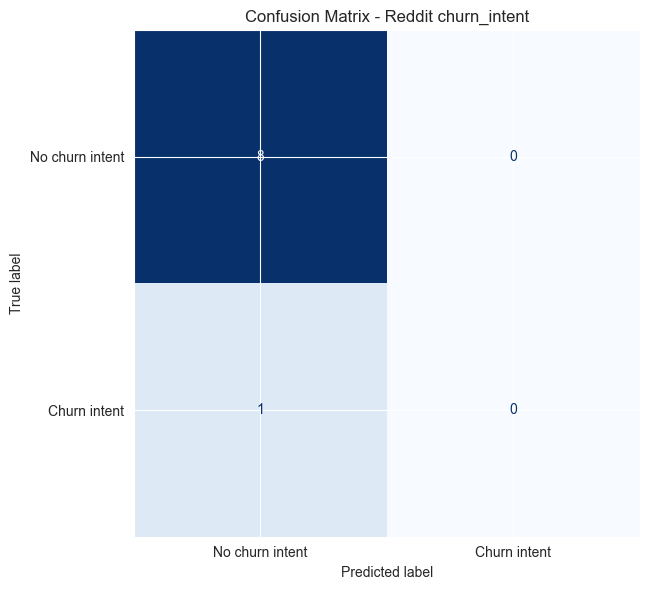

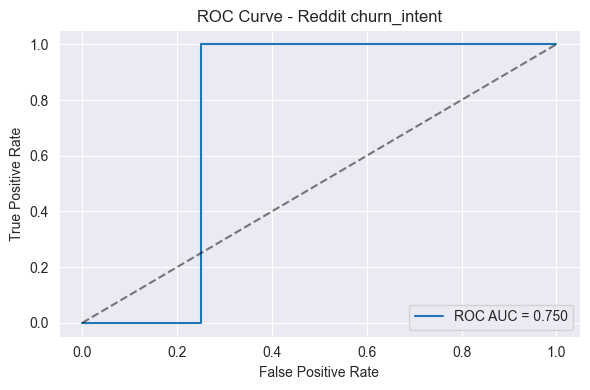

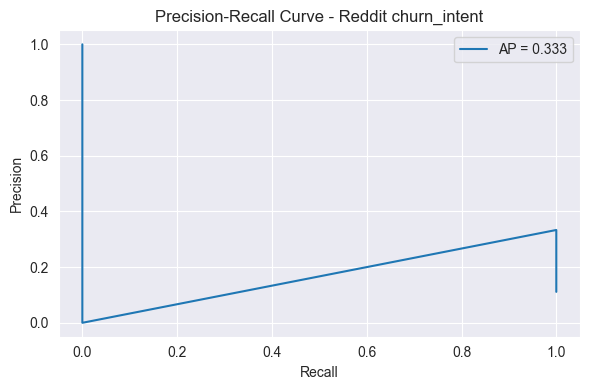

In [7]:
### Confusion Matrix

cm = confusion_matrix(y_test, y_pred_test, labels=[0, 1])
fig_cm, ax_cm = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No churn intent", "Churn intent"],
)
disp.plot(
    ax=ax_cm,
    cmap="Blues",
    colorbar=False,
    values_format="d",  # muestra enteros
)
ax_cm.set_title("Confusion Matrix - Reddit churn_intent")
ax_cm.set_xlabel("Predicted label")
ax_cm.set_ylabel("True label")
fig_cm.tight_layout()
fig_cm.savefig(os.path.join(eda_config.out_dir, "reddit_churn_text_confusion_matrix.png"))

### ROC Curve

fpr, tpr, _ = roc_curve(y_test, y_proba_test)
fig_roc, ax_roc = plt.subplots(figsize=(6, 4))
ax_roc.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}")
ax_roc.plot([0, 1], [0, 1], "k--", alpha=0.5)
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.set_title("ROC Curve - Reddit churn_intent")
ax_roc.legend(loc="lower right")
fig_roc.tight_layout()
fig_roc.savefig(os.path.join(eda_config.out_dir, "reddit_churn_text_roc_curve.png"))

### Precision-Recall Curve

prec, rec, _ = precision_recall_curve(y_test, y_proba_test)
fig_pr, ax_pr = plt.subplots(figsize=(6, 4))
ax_pr.plot(rec, prec, label=f"AP = {avg_precision:.3f}")
ax_pr.set_xlabel("Recall")
ax_pr.set_ylabel("Precision")
ax_pr.set_title("Precision-Recall Curve - Reddit churn_intent")
ax_pr.legend(loc="upper right")
fig_pr.tight_layout()
fig_pr.savefig(os.path.join(eda_config.out_dir, "reddit_churn_text_pr_curve.png"))

In [8]:
### Generate nlp_churn_score for all comments

comments_df["nlp_churn_score"] = churn_text_model.predict_proba(X)[:, 1]

comments_df[["body", "churn_signal", "nlp_churn_score"]].head(10)

,body,churn_signal,nlp_churn_score
0,"No es que son 5000, son 5000 por cada persona ...",0,0.356060
1,"Lo hacen de toda la vida. Antes eran los ""SMS ...",0,0.351282
2,por eso mismo me fui de personal en su momento...,1,0.654870
3,"Telefono pre pago, desde el Nokia 1100 hasta d...",0,0.343647
4,36 LUCAS POR 6GB!!!! KJJJ \r\nLiteralmente por...,1,0.656708
5,5mil pesos?\r\n\r\nCon 5mil pesos me compro ha...,0,0.334846
6,Cómo llego a esa pantalla en la app?,0,0.353547
7,"Aguante el prepago, le cargas cuando querés.yo...",0,0.345502
8,Esta semana me cambié a Tuenti por estas cuest...,1,0.655721
9,Lo pagas un poco mas barato que yo!\r\n\r\nYo ...,0,0.378833


In [9]:
### Save the labeled comments dataset

_ = save_df(
    comments_df,
    filename="data/processed/reddit_comments_with_nlp_score",
    fmt="csv",
    index=False,
)

2025-11-29 22:56:01,426 | src.data_loader | INFO | DataFrame saved: data\processed\reddit_comments_with_nlp_score.csv | Shape: (44, 9)
2025-11-29 22:56:01,429 | src.data_loader | INFO | Completed: save_df


2025-11-29 22:56:01,693 | src.eda | INFO | Plot saved: reports/figures/reddit-comments-nlp\reddit_nlp_churn_score_distribution.png
2025-11-29 22:56:01,695 | src.data_loader | INFO | Completed: wrapper


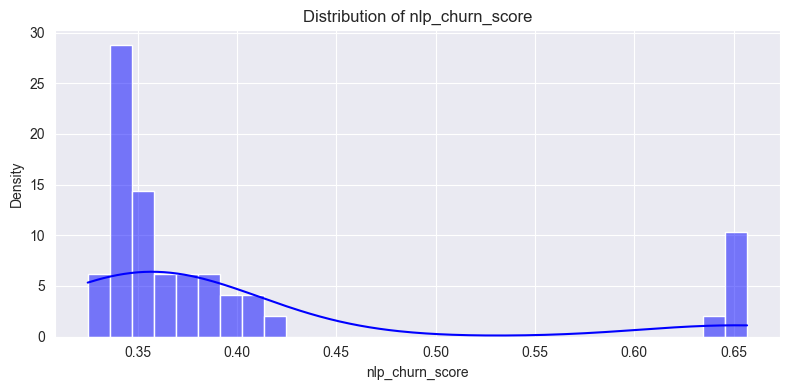

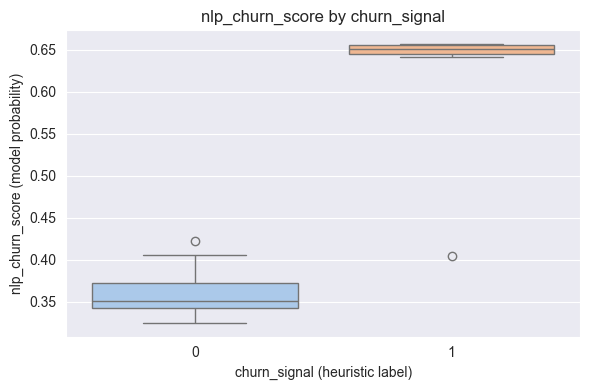

In [10]:
### EDA – Distribution of nlp_churn_score

fig_score, axes_score = plot_numerical_distributions(
    comments_df,
    numerical_cols=["nlp_churn_score"],
    save=True,
    fig_name="reddit_nlp_churn_score_distribution",
)

# churn_signal
fig_box, ax_box = plt.subplots(figsize=(6, 4))
sns.boxplot(
    data=comments_df,
    x="churn_signal",
    y="nlp_churn_score",
    palette="pastel",
    ax=ax_box,
)
ax_box.set_title("nlp_churn_score by churn_signal")
ax_box.set_xlabel("churn_signal (heuristic label)")
ax_box.set_ylabel("nlp_churn_score (model probability)")
fig_box.tight_layout()
fig_box.savefig(os.path.join(eda_config.out_dir, "reddit_nlp_churn_score_by_label.png"))

## Results and Insights from Notebook 07

In this notebook we:

1. Loaded the **curated Reddit comments dataset** produced in Notebook 06.
2. Trained a **Logistic Regression churn-intent model** (`churn_text_model`) on top of:
   - `TextCleaner` (Spanish text normalization).
   - TF-IDF (unigrams + bigrams, capped vocabulary).
   - Optional SVD for dimensionality reduction.
3. Evaluated the model using:
   - Classification report on a held-out test set.
   - Confusion matrix, ROC curve (ROC AUC), and Precision-Recall curve (Average Precision).
4. Generated a **text-based churn risk score**, `nlp_churn_score`, for every Reddit comment.
5. Saved the enriched dataset as:
   - `data/processed/reddit_comments_with_nlp_score_*.csv`
   containing `body`, `churn_signal` and `nlp_churn_score`.

### How to Integrate This with the Telco Churn Pipeline

Even though Reddit comments are not directly linked to the Telco Customer Churn dataset, this notebook demonstrates a **pattern** that can be applied in production:

1. For each new support interaction (ticket, chat, call transcript, social media comment):
   - Run `churn_text_model` to obtain an `nlp_churn_score` between 0 and 1.
2. Aggregate `nlp_churn_score` at **customer level**, for example:
   - Max score in the last 30 days.
   - Average score over a rolling window.
   - Count of comments above a chosen high-risk threshold.
3. Add these aggregated text scores as **additional features** to the Telco churn feature set:
   - `nlp_churn_score_max_30d`
   - `nlp_churn_score_mean_90d`, etc.
4. Retrain the structured churn model (from previous notebooks) including these features, and:
   - Measure uplift in ROC AUC / Recall at top k%.
   - Use SHAP or coefficients to explain the incremental value of text-based signals.

This closes the experimentation loop with a **hybrid approach**:
- Structured signals (contracts, billing, usage).
- Unstructured signals (text feedback turned into `nlp_churn_score`).

---

### Next Steps (Beyond the Scope of This Notebook)

- Connect real customer identifiers to text events to implement the aggregation strategies.
- Deploy `churn_text_model` as a microservice or batch process for scoring new text data.
- Integrate aggregated scores into the **production Telco churn pipeline** and monitor performance over time.

---

### Author

<a href="https://www.linkedin.com/in/flavio-aguirre-12784a252/">**Flavio Aguirre**</a><br>
<a href="https://coursera.org/share/e27ae5af81b56f99a2aa85289b7cdd04">***Data Scientist***</a>